In this sheet we will analyze the basic statistics of the scrapped data.
We will categorize them according to:
- rooms
- seller
- location (later)

What we will want to know:


In [76]:
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt

Get the database

In [77]:
df = pd.read_csv('database.csv')
df.head()

,ID,PRICE,SIZE,ROOMS,DATE,OWNER,LAT,LON
0,67837996,549000,45.62,2,29.04.2026,prywatny,50.656732,17.897874
1,67953693,710000,60.00,3,28.04.2026,prywatny,50.666950,17.937210
2,67954267,639000,64.12,3,28.04.2026,biuro nieruchomości,50.664387,17.933162
3,67926507,460000,46.61,3,28.04.2026,biuro nieruchomości,50.662900,17.897750
4,67686199,779000,75.61,4,28.04.2026,biuro nieruchomości,50.650100,17.854300


How many positions are there for private/agency offers?

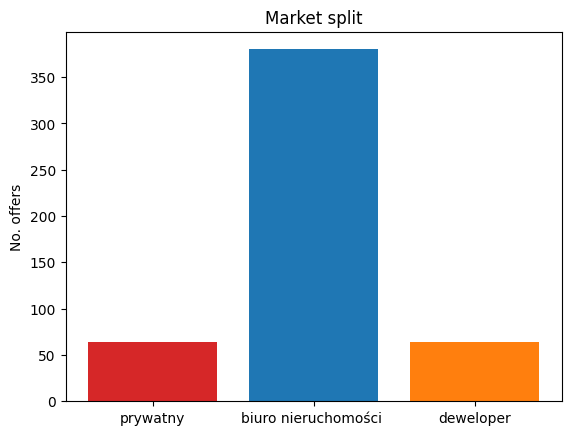

In [78]:
owners = df["OWNER"].unique()

private_offers = df[df["OWNER"] == owners[0]]
agency_offers = df[df["OWNER"] == owners[1]]
developer_offers = df[df["OWNER"] == owners[2]]

private_num = len(private_offers)
agency_num = len(agency_offers)
developer_num = len(developer_offers)


fig, ax = plt.subplots()

values = [private_num,agency_num,developer_num]
bar_labels = owners
bar_colors = ['tab:red', 'tab:blue', 'tab:orange']

ax.bar(owners, values, label=bar_labels, color=bar_colors)
ax.set_ylabel('No. offers')
ax.set_title('Market split')

plt.show()


# Agency offers


What is the price distribution?

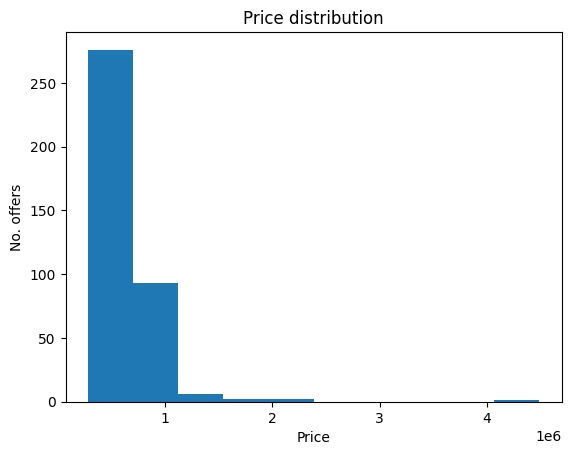

In [79]:
plt.hist(agency_offers["PRICE"],bins = 10)
plt.title("Price distribution")
plt.xlabel("Price")
plt.ylabel("No. offers")
plt.show()

This implies that there are many outliers on the right side, lets filter out the offer that have a price higher than 1M.


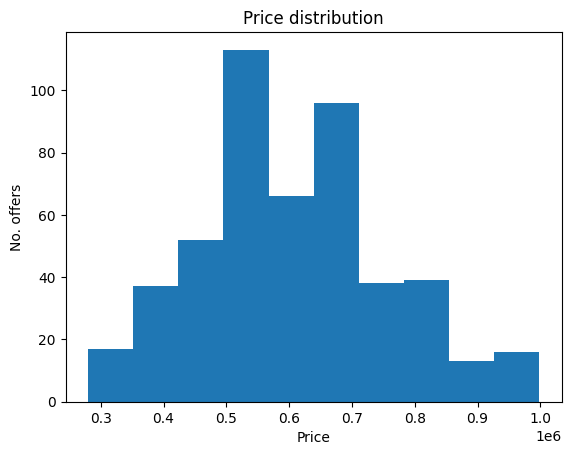

In [ ]:
df_resonable = df[df["PRICE"]<=1000000]

plt.hist(df_resonable["PRICE"],bins = 10)
plt.title("Price distribution")
plt.xlabel("Price")
plt.ylabel("No. offers")
plt.show()

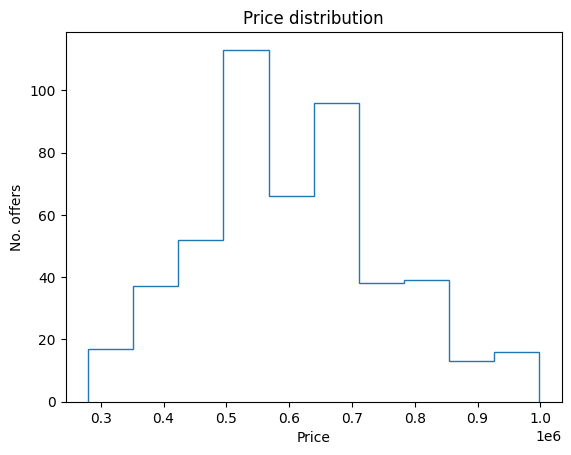

In [91]:

# inna metoda na narysowanie histogramu
count,bins = np.histogram(df_resonable["PRICE"])
plt.stairs(count,bins)
plt.title("Price distribution")
plt.xlabel("Price")
plt.ylabel("No. offers")
plt.show()

Lets use matplotlib to put all the offers on on histogram, with distinction of the owner.

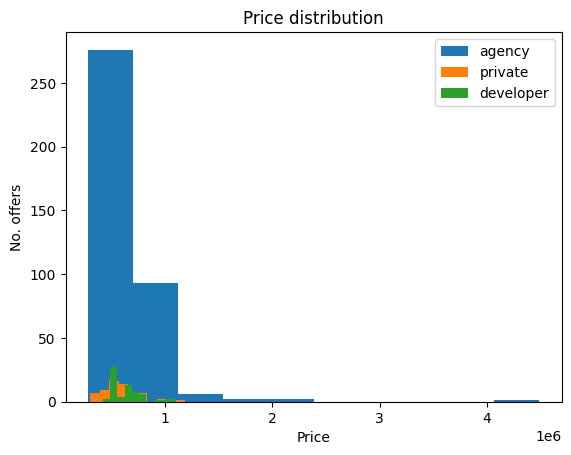

In [82]:
plt.hist(agency_offers["PRICE"],bins = 10, label="agency")
plt.hist(private_offers["PRICE"],bins = 10, label="private")
plt.hist(developer_offers["PRICE"],bins = 10, label="developer")
plt.title("Price distribution")
plt.xlabel("Price")
plt.ylabel("No. offers")
plt.legend()
plt.show()

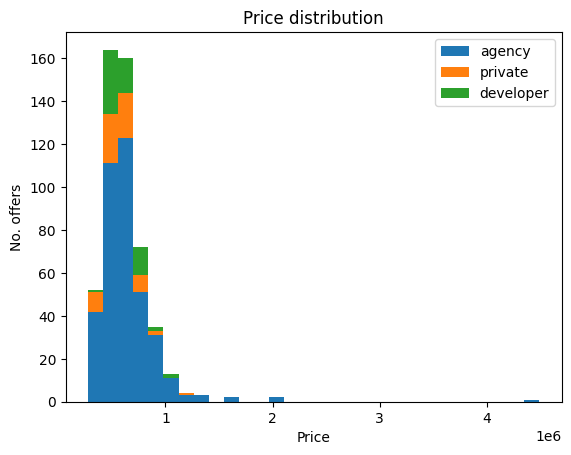

In [83]:
plt.hist([agency_offers["PRICE"],private_offers["PRICE"],developer_offers["PRICE"]],bins = 30, stacked=True, label=["agency","private","developer"])
plt.title("Price distribution")
plt.xlabel("Price")
plt.ylabel("No. offers")
plt.legend()
plt.show()

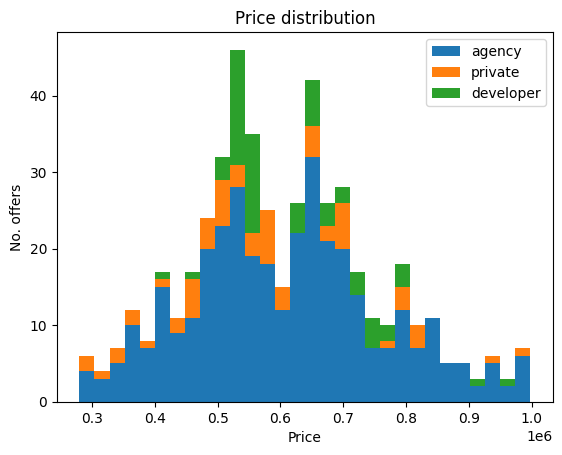

In [84]:
agency_reasonable_offers = agency_offers[agency_offers["PRICE"]<=1000000]
private_reasonable_offers = private_offers[private_offers["PRICE"]<=1000000]
developer_reasonable_offers = developer_offers[developer_offers["PRICE"]<=1000000]

plt.hist([agency_reasonable_offers["PRICE"],private_reasonable_offers["PRICE"],developer_reasonable_offers["PRICE"]],bins = 30, stacked=True, label=["agency","private","developer"])
plt.title("Price distribution")
plt.xlabel("Price")
plt.ylabel("No. offers")
plt.legend()
plt.show()

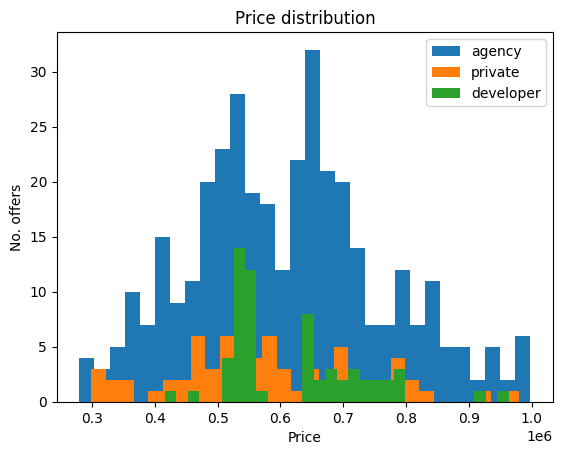

In [85]:
plt.hist(agency_reasonable_offers["PRICE"],bins = 30, label="agency")
plt.hist(private_reasonable_offers["PRICE"],bins = 30, label="private")
plt.hist(developer_reasonable_offers["PRICE"],bins = 30, label="developer")
plt.title("Price distribution")
plt.xlabel("Price")
plt.ylabel("No. offers")
plt.legend()
plt.show()

This is some nice looking data, but it doesnt tell us how the price corresponds to the size of the flat. Lets calculate that.
We will calculate that with respect to the owner, and then all offers together.

In [86]:
agency_sqr_price = agency_offers["PRICE"]/agency_offers["SIZE"]
private_sqr_price = private_offers["PRICE"]/private_offers["SIZE"]
developer_sqr_price = developer_offers["PRICE"]/developer_offers["SIZE"]
print(np.mean(agency_sqr_price),np.mean(private_sqr_price),np.mean(developer_sqr_price))

sqr_price = df["PRICE"]/df["SIZE"]
print(np.mean(sqr_price))

10458.096967712985 11286.879637786864 10513.211946236075
10569.454151788197


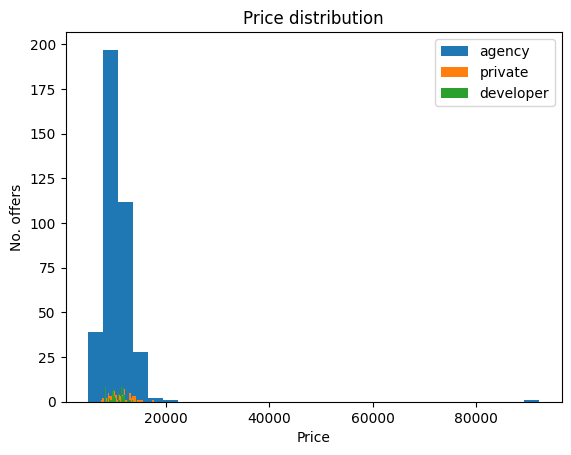

In [87]:
plt.hist(agency_sqr_price,bins = 30, label="agency")
plt.hist(private_sqr_price,bins = 30, label="private")
plt.hist(developer_sqr_price,bins = 30, label="developer")
plt.title("Price distribution")
plt.xlabel("Price")
plt.ylabel("No. offers")
plt.legend()
plt.show()

Look like we have another outlier, no one will pay for that lmao.

In [88]:
print(agency_sqr_price.max())
agency_sqr_price = agency_sqr_price.drop(agency_sqr_price.idxmax())
print(agency_sqr_price.max())

92197.1252566735
20000.0


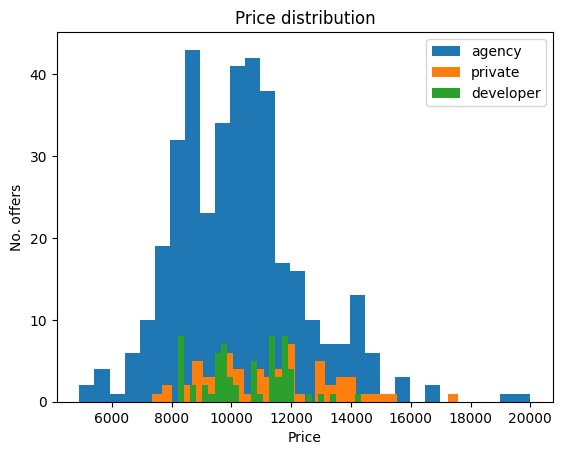

In [89]:
plt.hist(agency_sqr_price,bins = 30, label="agency")
plt.hist(private_sqr_price,bins = 30, label="private")
plt.hist(developer_sqr_price,bins = 30, label="developer")
plt.title("Price distribution")
plt.xlabel("Price")
plt.ylabel("No. offers")
plt.legend()
plt.show()

Looks way better now

w zależności od pokojów:
rozmiar
cena za metr kwadratowy
market split


Lets analyze the market split based on the number of rooms

In [ ]:
owners = df["OWNER"].unique()

private_offers = df[df["OWNER"] == owners[0]]
agency_offers = df[df["OWNER"] == owners[1]]
developer_offers = df[df["OWNER"] == owners[2]]

private_num = len(private_offers)
agency_num = len(agency_offers)
developer_num = len(developer_offers)


fig, ax = plt.subplots()

values = [private_num,agency_num,developer_num]
bar_labels = owners
bar_colors = ['tab:red', 'tab:blue', 'tab:orange']

ax.bar(owners, values, label=bar_labels, color=bar_colors)
ax.set_ylabel('No. offers')
ax.set_title('Market split')

plt.show()